In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt

In [22]:
data = pd.read_csv("/content/diabetes.csv")
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [23]:
data.shape

(768, 9)

In [24]:
data.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [25]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [26]:
data.duplicated().sum()

np.int64(0)

In [27]:
X = data.drop("Outcome", axis=1)
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [28]:
y = data["Outcome"]
print(y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
print(X_test)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
668            6       98             58             33      190  34.0   
324            2      112             75             32        0  35.7   
624            2      108             64              0        0  30.8   
690            8      107             80              0        0  24.6   
473            7      136             90              0        0  29.9   
..           ...      ...            ...            ...      ...   ...   
355            9      165             88              0        0  30.4   
534            1       77             56             30       56  33.3   
344            8       95             72              0        0  36.8   
296            2      146             70             38      360  28.0   
462            8       74             70             40       49  35.3   

     DiabetesPedigreeFunction  Age  
668                     0.430   43  
324                     0.148   21  


In [35]:
print(X_train)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
60             2       84              0              0        0   0.0   
618            9      112             82             24        0  28.2   
346            1      139             46             19       83  28.7   
294            0      161             50              0        0  21.9   
231            6      134             80             37      370  46.2   
..           ...      ...            ...            ...      ...   ...   
71             5      139             64             35      140  28.6   
106            1       96            122              0        0  22.4   
270           10      101             86             37        0  45.6   
435            0      141              0              0        0  42.4   
102            0      125             96              0        0  22.5   

     DiabetesPedigreeFunction  Age  
60                      0.304   21  
618                     1.282   50  


In [36]:
print(y_test)

668    0
324    0
624    0
690    0
473    0
      ..
355    1
534    0
344    0
296    1
462    0
Name: Outcome, Length: 154, dtype: int64


In [37]:
print(y_train)

60     0
618    1
346    0
294    0
231    1
      ..
71     0
106    0
270    1
435    1
102    0
Name: Outcome, Length: 614, dtype: int64


In [30]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [31]:
y_pred = knn.predict(X_test)

In [32]:
for actual, predicted in zip(y_test, y_pred):
  if actual == predicted:
    print("Correct Prediction:",
          "Actual= ",actual,
          "Predicted = ", predicted)
  else:
     print("Wrong Prediction:",
          "Actual= ",actual,
          "Predicted = ", predicted)

Correct Prediction: Actual=  0 Predicted =  0
Wrong Prediction: Actual=  0 Predicted =  1
Correct Prediction: Actual=  0 Predicted =  0
Wrong Prediction: Actual=  0 Predicted =  1
Wrong Prediction: Actual=  0 Predicted =  1
Wrong Prediction: Actual=  0 Predicted =  1
Correct Prediction: Actual=  0 Predicted =  0
Correct Prediction: Actual=  0 Predicted =  0
Wrong Prediction: Actual=  0 Predicted =  1
Wrong Prediction: Actual=  0 Predicted =  1
Wrong Prediction: Actual=  1 Predicted =  0
Wrong Prediction: Actual=  0 Predicted =  1
Wrong Prediction: Actual=  1 Predicted =  0
Correct Prediction: Actual=  0 Predicted =  0
Correct Prediction: Actual=  0 Predicted =  0
Correct Prediction: Actual=  1 Predicted =  1
Correct Prediction: Actual=  0 Predicted =  0
Correct Prediction: Actual=  0 Predicted =  0
Correct Prediction: Actual=  1 Predicted =  1
Correct Prediction: Actual=  1 Predicted =  1
Wrong Prediction: Actual=  0 Predicted =  1
Correct Prediction: Actual=  0 Predicted =  0
Wrong Pr

In [33]:
print("Accuracy = ",knn.score(X_test, y_test))

Accuracy =  0.6493506493506493


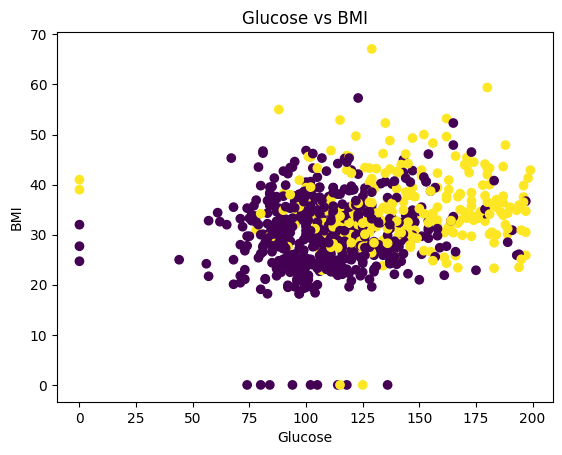

In [40]:
df = pd.DataFrame(data)
plt.scatter(df["Glucose"], df["BMI"], c=df["Outcome"])

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI")
plt.show()